**Análise de dados sobre o dataset de Detecção de Emoções em Texto** - 1ª Atividade de LIA

Estudante: Gustavo Ribeiro E Barros

Matrícula: 202503242


## 🎯 Objetivo do Desafio

Este notebook aplica o fluxo de análise de dados descritos em notebooks trabalhados em sala sobre um dataset de **texto rotulado com emoções**.

## 📦 Sobre o Dataset

**Emotions Detection Text Dataset**, no Kaggle,
🔗 https://www.kaggle.com/datasets/abhrajaiswal/emotions-detection-text-dataset


O arquivo (`emotions.txt`) contém **16.000 frases em inglês**, cada uma rotulada com uma entre **6 emoções**: `joy`, `sadness`, `anger`, `fear`, `love`, `surprise`. Cada linha segue o formato `texto;emoção`.

## 🗂️ Estrutura deste notebook
1. Importação das bibliotecas
2. Carregamento do dataset
3. Exploração inicial e identificação das colunas
4. Diagnóstico de qualidade dos dados
5. Limpeza dos dados
6. Engenharia de atributos
7. Visualizações exploratórias
8. Conclusão e Insights


## 📚 1. Importação das Bibliotecas

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

## 📥 2. Carregando o Dataset

O arquivo do dataset (`emotions.txt`) **não é um CSV com cabeçalho** — é um arquivo de texto puro, com uma frase por linha, no formato:

```
texto da frase;emoção
```

separado por **ponto e vírgula (`;`)**, sem nomes de coluna na primeira linha. A leitura correta usa `sep=';'` e `header=None`, atribuindo os nomes das colunas manualmente.

In [6]:
# Faça upload do arquivo emotions.txt no Colab (ícone de pasta à esquerda > upload).
# O arquivo necessário está também na pasta "Entrega 1 - Gustavo Barros" no Github.

caminho_arquivo = "emotions.txt"

df = pd.read_csv(
    caminho_arquivo,
    sep=';',
    header=None,       # o arquivo não tem linha de cabeçalho
    names=['text', 'emotion']  # nomeando as colunas manualmente
)

print(f"📏 Dimensões: {df.shape}")
df.head()

📏 Dimensões: (16000, 2)


,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


## 🔍 3. Exploração Inicial e Identificação das Colunas

In [22]:
possiveis_texto = ['text', 'Text', 'content', 'sentence', 'tweet', 'Comment']
possiveis_label = ['emotion', 'Emotion', 'label', 'Label', 'sentiment', 'Sentiment']

col_texto = next((c for c in possiveis_texto if c in df.columns), None)
col_label = next((c for c in possiveis_label if c in df.columns), None)

print(f"Coluna de texto identificada: {col_texto}")
print(f"Coluna de rótulo identificada: {col_label}")

Coluna de texto identificada: text
Coluna de rótulo identificada: emotion


In [23]:
# Confirme visualmente se a detecção está correta
df[[col_texto, col_label]].sample(5)

,text,emotion
4007,i am tired of feeling awful,sadness
3238,im not feeling exactly thrilled with standing ...,joy
14267,im still contagious and while i am desperately...,sadness
14584,i feel like the earthquake has also shaken the...,fear
13216,i feel weird taking up time and making these s...,surprise


## 🧪 4. Diagnóstico de Qualidade dos Dados

In [27]:
print("Valores ausentes por coluna:")
print(df.isnull().sum())
print()
print(f"Linhas duplicadas (linha inteira): {df.duplicated().sum()}")
print(f"Linhas duplicadas (considerando apenas o texto): {df.duplicated(subset=[col_texto]).sum()}")
print()
print("Distribuição das classes (emoções):")
print(df[col_label].value_counts())

Valores ausentes por coluna:
text       0
emotion    0
dtype: int64

Linhas duplicadas (linha inteira): 1
Linhas duplicadas (considerando apenas o texto): 31

Distribuição das classes (emoções):
emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


## 🧹 5. Limpeza dos Dados

In [28]:
df_limpo = df.copy()

# Remove linhas sem texto ou sem rótulo
df_limpo = df_limpo.dropna(subset=[col_texto, col_label])

# Remove duplicatas exatas de texto
df_limpo = df_limpo.drop_duplicates(subset=[col_texto])

print(f"Linhas antes: {len(df)} | Linhas depois: {len(df_limpo)}")

Linhas antes: 16000 | Linhas depois: 15969


In [31]:
def limpar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)          # remove URLs
    texto = re.sub(r'@\w+', '', texto)                     # remove menções
    texto = re.sub(r'#\w+', '', texto)                     # remove hashtags
    texto = re.sub(r'\d+', '', texto)                       # remove números
    texto = texto.translate(str.maketrans('', '', string.punctuation))  # remove pontuação
    texto = re.sub(r'\s+', ' ', texto).strip()              # remove espaços extras
    return texto

df_limpo['texto_limpo'] = df_limpo[col_texto].apply(limpar_texto)
df_limpo[[col_texto, 'texto_limpo']].sample(5)

,text,texto_limpo
3239,i feel disturbed betrayed untrustworthy slight...,i feel disturbed betrayed untrustworthy slight...
13292,i feel so idiotic all the sudden,i feel so idiotic all the sudden
11706,i cant help but feel how much burdened my pare...,i cant help but feel how much burdened my pare...
8644,i feel like i have doomed myself to failure,i feel like i have doomed myself to failure
1426,i feel frustrated and upset and demotivated wh...,i feel frustrated and upset and demotivated wh...


## 📊 7. Visualizações dos Dados

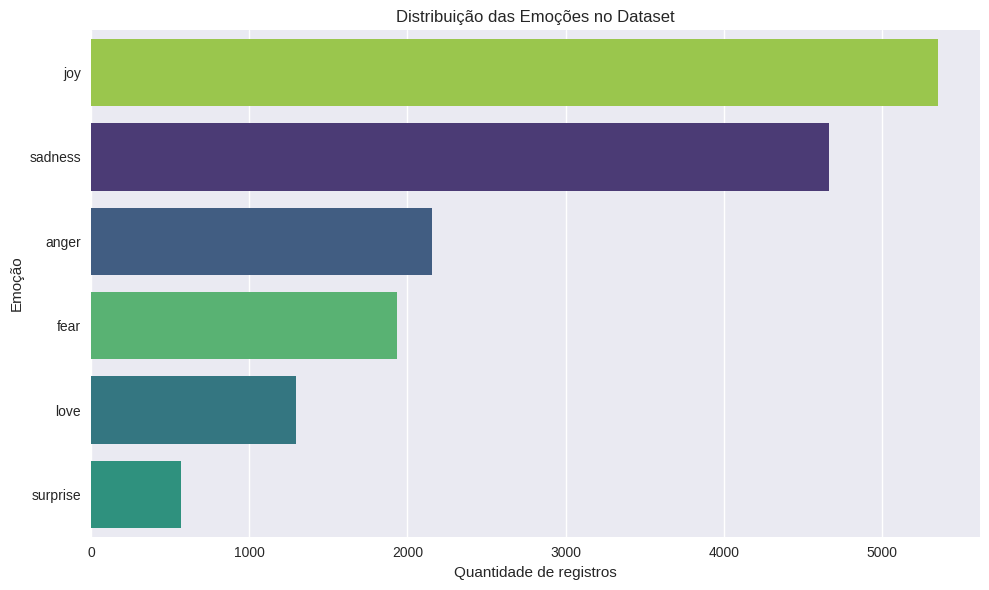

In [15]:
# Distribuição das classes
plt.figure(figsize=(10, 6))
ordem = df_limpo[col_label].value_counts().index
sns.countplot(y=col_label, data=df_limpo, order=ordem, hue=col_label, palette='viridis', legend=False)
plt.title('Distribuição das Emoções no Dataset')
plt.xlabel('Quantidade de registros')
plt.ylabel('Emoção')
plt.tight_layout()
plt.show()

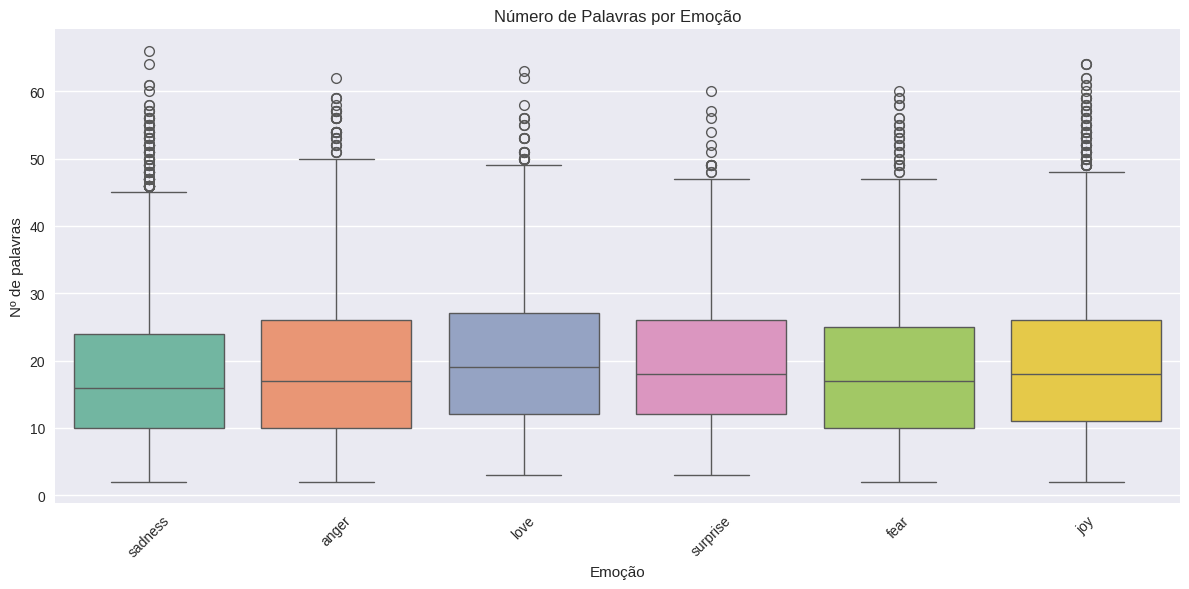

In [17]:
# Comprimento do texto por emoção
plt.figure(figsize=(12, 6))
sns.boxplot(x=col_label, y='num_palavras', data=df_limpo, hue=col_label, palette='Set2', legend=False)
plt.title('Número de Palavras por Emoção')
plt.xlabel('Emoção')
plt.ylabel('Nº de palavras')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🧹 Removendo *stopwords* antes de contar palavras

**O que são:** palavras muito frequentes em qualquer texto da língua (ex.: `i`, `the`, `a`, `and`, `to`, `of`), que carregam pouco significado por si só — servem à gramática, não ao conteúdo.

**Por que remover:** sem esse filtro, a contagem de palavras mais frequentes é dominada pelas mesmas palavras em todas as classes, escondendo o que de fato diferencia uma emoção da outra. Isso é visível logo abaixo: a primeira contagem (sem filtro) mostra basicamente as mesmas palavras genéricas em todas as emoções.

Além das stopwords genéricas do inglês (via `sklearn`), este dataset tem uma particularidade: como as frases foram coletadas a partir do padrão *"I feel..."*, palavras como `feel`, `feeling`, `like`, `just`, `really` também aparecem em praticamente todas as classes — funcionando como **stopwords específicas do domínio**. Por isso, elas são incluídas manualmente na lista de exclusão.

In [32]:
# Frequência de palavras SEM remover stopwords (para efeito de comparação)
print("🔸 Top 10 palavras mais frequentes (SEM remover stopwords) — dataset completo:")
todas_palavras = ' '.join(df_limpo['texto_limpo']).split()
print(Counter(todas_palavras).most_common(10))

🔸 Top 10 palavras mais frequentes (SEM remover stopwords) — dataset completo:
[('i', 25811), ('feel', 11157), ('and', 9574), ('to', 8960), ('the', 8355), ('a', 6190), ('feeling', 5108), ('that', 5105), ('of', 4978), ('my', 4277)]


In [19]:
# Stopwords genéricas do inglês + stopwords específicas do domínio deste dataset
stopwords_dominio = {
    'feel', 'feeling', 'feelings', 'im', 'ive', 'get', 'got',
    'one', 'really', 'just', 'like', 'know', 'make', 'made', 'way', 'things', 'little'
}
stopwords_completas = ENGLISH_STOP_WORDS.union(stopwords_dominio)

# Palavras mais frequentes por emoção, agora SEM stopwords
frequencias_por_emocao = {}
for emocao in df_limpo[col_label].unique():
    textos = df_limpo.loc[df_limpo[col_label] == emocao, 'texto_limpo']
    palavras = ' '.join(textos).split()
    palavras_filtradas = [p for p in palavras if p not in stopwords_completas and len(p) > 2]
    frequencias_por_emocao[emocao] = Counter(palavras_filtradas).most_common(10)

    print(f"\n🔹 {emocao}:")
    print(frequencias_por_emocao[emocao])


🔹 sadness:
[('time', 199), ('want', 179), ('people', 176), ('life', 176), ('think', 175), ('bit', 169), ('dont', 158), ('day', 137), ('going', 129), ('pretty', 120)]

🔹 anger:
[('time', 118), ('people', 105), ('want', 98), ('angry', 85), ('think', 81), ('bit', 77), ('dont', 70), ('irritable', 70), ('cold', 68), ('don', 68)]

🔹 love:
[('love', 97), ('loving', 68), ('time', 68), ('sweet', 67), ('want', 65), ('caring', 62), ('passionate', 61), ('life', 56), ('sympathetic', 55), ('hot', 55)]

🔹 surprise:
[('amazed', 67), ('impressed', 61), ('overwhelmed', 58), ('surprised', 55), ('weird', 55), ('curious', 54), ('funny', 49), ('shocked', 45), ('strange', 43), ('amazing', 40)]

🔹 fear:
[('bit', 116), ('people', 87), ('want', 85), ('time', 83), ('strange', 77), ('think', 75), ('nervous', 75), ('terrified', 74), ('going', 72), ('anxious', 71)]

🔹 joy:
[('time', 290), ('want', 203), ('people', 203), ('think', 198), ('good', 196), ('love', 191), ('pretty', 184), ('life', 181), ('going', 179), (

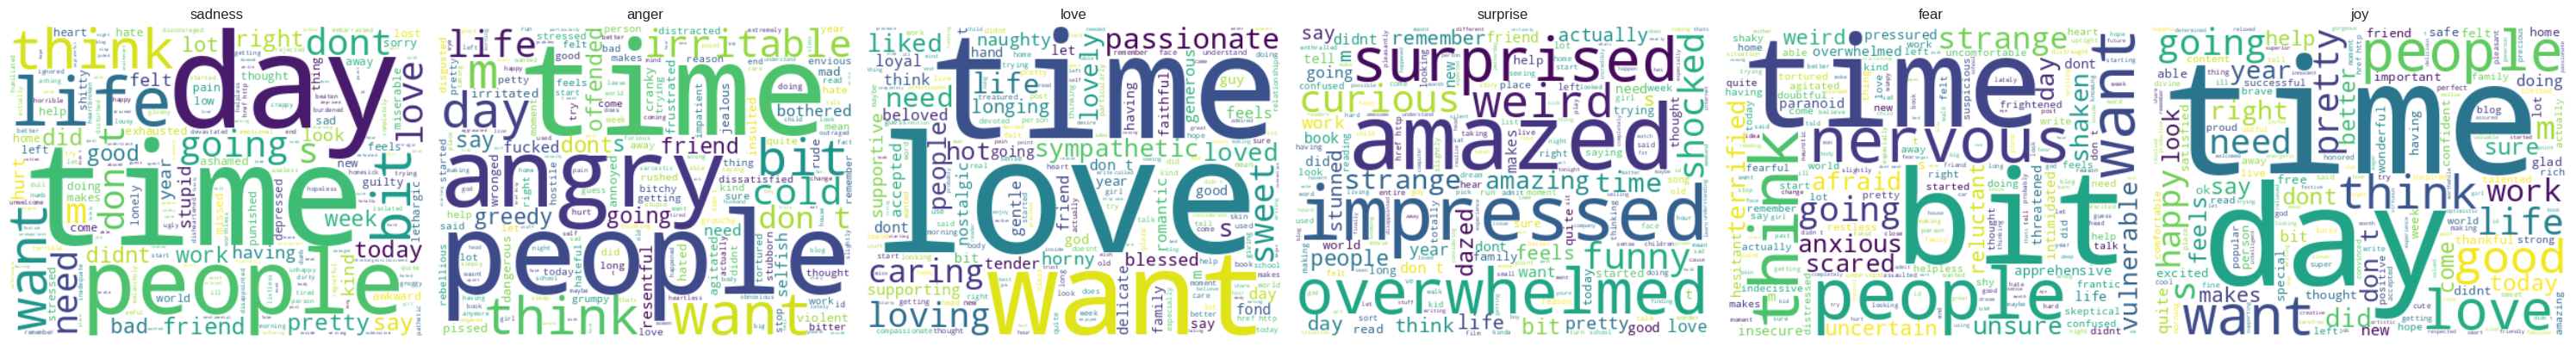

In [20]:
# Para vizualizar o dataset de forma mais gráfica, usando o WordCloud é possível observer as palavras como uma núvem
# de palavras por emoção

from wordcloud import WordCloud

emocoes = df_limpo[col_label].unique()
fig, axes = plt.subplots(1, len(emocoes), figsize=(5 * len(emocoes), 5))

for ax, emocao in zip(axes, emocoes):
    texto_emocao = ' '.join(df_limpo.loc[df_limpo[col_label] == emocao, 'texto_limpo'])
    wc = WordCloud(
        width=400, height=300, background_color='white',
        stopwords=stopwords_completas
    ).generate(texto_emocao)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(emocao)
    ax.axis('off')

plt.tight_layout()
plt.show()

---

## 📝 8. Conclusão e Insights

In [21]:
# Resumo curto dos valores das classes (emoções) do dataset.
dist = df_limpo[col_label].value_counts()
razao_desbalanceamento = round(dist.max() / dist.min(), 1)
comprimento_medio = df_limpo.groupby(col_label)['num_palavras'].mean().sort_values(ascending=False)

print("Distribuição das classes:")
print(dist)
print(f"\nRazão entre a maior e a menor classe: {razao_desbalanceamento}x")
print("\nComprimento médio (palavras) por emoção:")
print(comprimento_medio)

Distribuição das classes:
emotion
joy         5350
sadness     4664
anger       2155
fear        1933
love        1299
surprise     568
Name: count, dtype: int64

Razão entre a maior e a menor classe: 9.4x

Comprimento médio (palavras) por emoção:
emotion
love        20.719015
surprise    20.052817
joy         19.502243
anger       19.239443
fear        18.839628
sadness     18.359134
Name: num_palavras, dtype: float64


### 1️⃣ Desbalanceamento de classes

O dataset é desbalanceado: `joy` (≈5.350 registros) e `sadness` (≈4.660) dominam o conjunto, enquanto `surprise` tem pouco mais de 550 exemplos — uma razão de aproximadamente **9x** entre a classe mais e a menos frequente.

**Implicação prática:** se esse dataset for usado futuramente para treinar um classificador, esse desbalanceamento tende a enviesar o modelo em favor de `joy`/`sadness`, e a classe `surprise` (a mais rara) provavelmente será a mais difícil de prever bem.

### 2️⃣ Stopwords: da contagem "genérica" para a "distintiva"

Antes de remover stopwords, as palavras mais frequentes eram praticamente idênticas entre as 6 emoções (`i`, `feel`, `and`, `to`, `the`...), o que dificulta a distinção entre as classes.

Depois de remover tanto as stopwords genéricas do inglês quanto as específicas do domínio (`feel`, `feeling`, `like`, `just`...), **encontramos palavras mais coerentes com cada emoção**:

- **`surprise`**: *amazed, impressed, overwhelmed, surprised, weird, curious, shocked*
- **`love`**: *love, loving, sweet, caring, passionate*
- **`fear`**: *nervous, terrified, strange*
- **`anger`**: *angry, irritable*
- **`joy`** e **`sadness`**: seguem dominadas por palavras mais genéricas do cotidiano (`time`, `people`, `want`, `life`, `think`), sugerindo que essas duas emoções são expressas de forma mais diluída em contextos variados, e não por um vocabulário emocional tão específico quanto `surprise` ou `love`.


### 3️⃣ Comprimento das frases por emoção

Frases de "love" e "surprise" tendem a ser um pouco mais longas (20-21 palavras) que as de "sadness" (18,4 palavras). Isso pode significar que demostrações de amor, afeto e felicidade tendem a possuir maior contexto e explicações. Por outro lado, pode-se pensar que declarações de tristeza são mais diretas e não muito detalhadas, e por isso a menor quantidade de palavras

### 🎯 Síntese

O dataset é rico para classificação de emoção, mas apresenta subrepresetação de uma das classes, como "surprise" (surpresa). Além disso, a redundância vocabular (stopwords) restringe o potencial do dataset, isto é, há uma repetição de palavras sem muito valor semântico em cada texto.